<a href="https://colab.research.google.com/github/hanshunyi0-cyber/taxi-eta/blob/main/website/public/modules/python-ai-engineering/challenges/aie-s4-taxi-eta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AIE S4 — Taxi Arrival Promise

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/racousin/data_science_practice/blob/main/website/public/modules/python-ai-engineering/challenges/aie-s4-taxi-eta.ipynb)

**Lab 1 of Session 4, PyTorch in a Nutshell.** Promise an arrival
time the ride beats 9 times out of 10.

Challenge: <https://ml-arena.com/viewchallenge/189>

---

A ride-hailing app shows an arrival time before the ride starts. For
each of 10,461 New York green-taxi trips you promise a duration in
minutes, and a minute late costs nine times as much as a minute of
padding:

$$L_{0.9}(y, \hat{y}) = \max(0.9\,(y - \hat{y}),\ -0.1\,(y - \hat{y}))$$

where $y$ is the trip's duration and $\hat{y}$ your promise. The
promise that minimises this loss is the **90th percentile** of the
duration, not its mean. So the network has to be trained on this
loss, and writing the training loop yourself is what lets you choose
it.

**The data.** 52,305 NYC TLC green-taxi trips from January 2024.
`X.csv` and `y.csv` hold the first 25 days, 41,844 trips in pickup
order; `X_submission.csv` holds the rest of the month, 10,461 trips,
shuffled. Twelve numeric features; the target is the duration in
minutes. `trip_distance` is the metered distance, known only once the
ride is over: a real app would use the length of the planned route,
and this data stands in with the metered one.


**What you write.** Seven cells. Each is followed by a check cell that
reads the names its `# TODO` states, and stops the notebook with a
message until the step works:


Everything else is given: the download, the split, the scaler, the
tensors, a scorer that computes what the leaderboard computes, the
chart, the checkpoint, the prediction and the submission. Run the
cells in order.



---

## 0. Setup

`torch`, `pandas`, `scikit-learn` and `matplotlib` ship with Colab.
The install adds the ML-Arena client, which downloads the data and
uploads your answer, and `wandb`, which logs the training curves. The
client's distribution is **`mlarena-sdk`** and it imports as
`mlarena`; `pip install mlarena` is an unrelated package.

In [1]:
!pip install -q mlarena-sdk wandb

In [2]:
import copy
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import wandb

torch.manual_seed(0)      # the same run every time on this machine (lesson 2)

### Weights & Biases: choose now

Step 5c logs every epoch to W&B (lesson 9, *Tracking with Weights &
Biases*). Choose one of two ways in the cell below, before you get
there:

- **With a free account**, about five minutes (GitHub sign-in works):
  create it at [wandb.ai](https://wandb.ai), uncomment
  `wandb.login()` and paste the key from
  [wandb.ai/authorize](https://wandb.ai/authorize). The run then
  appears online, one chart per number you log.
- **Without an account (or academic!)**: uncomment the `WANDB_MODE` line. The run is
  written to `./wandb` on this machine and never uploaded.

Either way, the chart after Step 5c draws both losses from the
notebook's own `history`, so nothing later depends on W&B.

In [4]:
# Uncomment ONE of the two lines, then run the cell.
wandb.login("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")                           # an account: paste the key from https://wandb.ai/authorize
# os.environ["WANDB_MODE"] = "offline"    # no account: the run stays in ./wandb, never uploaded
print("WANDB_MODE =", os.environ.get("WANDB_MODE", "not set: online, after wandb.login()"))

/usr/local/lib/python3.13/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: hanshunyi0 (hanshunyi0-sorbonne-universit-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


WANDB_MODE = not set: online, after wandb.login()


---

## 1. The data

Paste your personal API key from your ML-Arena **Profile** page: it
starts with `mlk_user_`, the same one as in Sessions 2 and 3. The cell
downloads `X.csv`, `y.csv` and `X_submission.csv` into the working
directory.

In [5]:
import mlarena

API_KEY = "mlk_user_3d46dbb737814134_5cf773dc3e52393eea5a6d938b78b0ba"   # <- paste yours here
CHALLENGE_ID = 189

client = mlarena.connect(api_key=API_KEY)
client.download_dataset(CHALLENGE_ID, ".")

['./X.csv', './y.csv', './X_submission.csv']

In [6]:
X = pd.read_csv("X.csv")
y = pd.read_csv("y.csv")
X_submission = pd.read_csv("X_submission.csv")
FEATURES = [c for c in X.columns if c != "id"]
print("X", X.shape, "  X_submission", X_submission.shape)
print(len(FEATURES), "features:", FEATURES)

X (41844, 13)   X_submission (10461, 13)
12 features: ['trip_distance', 'pickup_hour', 'day_of_week', 'is_weekend', 'pickup_manhattan', 'pickup_queens', 'pickup_brooklyn', 'pickup_bronx', 'dropoff_manhattan', 'dropoff_queens', 'dropoff_brooklyn', 'dropoff_bronx']


`y.csv` is `id,prediction`: each trip's duration in minutes, in the
row order of `X.csv`. The loss aims at the 90th percentile, so that is
the number to know before training anything.

In [7]:
durations = y["prediction"]
print(f"mean {durations.mean():.2f} min, median {durations.median():.2f}, "
      f"90th percentile {durations.quantile(0.9):.2f}")

mean 13.70 min, median 11.47, 90th percentile 24.70


---

## 2. A validation part, in time order

`X.csv` is in pickup order, and the leaderboard scores later days. So
hold out the **last** 20% of the rows (lesson 7): a random split would
put trips from the same hour on both sides and tell you less about
the days ahead.

In [8]:
n_fit = int(0.8 * len(X))           # rows are in pickup order: the last 20% validate
X_tr, X_val = X[FEATURES].iloc[:n_fit], X[FEATURES].iloc[n_fit:]
y_tr, y_val = y["prediction"].iloc[:n_fit], y["prediction"].iloc[n_fit:]
print(len(X_tr), "training rows,", len(X_val), "validation rows")

# to notice a proper test set would be the only best way to evaluate, as you will only run few experiments, the bias is acceptable

33475 training rows, 8369 validation rows


`leaderboard_score` computes what the leaderboard computes, the mean
pinball loss negated and the share of promises kept, for any
predictions whose truth you hold. It is how you compare variants
without spending a submission. A constant promise, the training
part's 90th percentile, sets the floor:

In [9]:
TAU = 0.9


def leaderboard_score(pred, truth):
    """(-pinball, % of promises kept), as the leaderboard computes them."""
    d = np.asarray(truth, dtype=float) - np.asarray(pred, dtype=float)
    neg_pinball = -np.mean(np.maximum(TAU * d, (TAU - 1) * d))
    return float(neg_pinball), float(100 * np.mean(d <= 0))


constant = y_tr.quantile(TAU)
const_score, const_kept = leaderboard_score(np.full(len(y_val), constant), y_val)
print(f"always {constant:.2f} min, on the validation part: "
      f"-pinball {const_score:.4f}, {const_kept:.1f}% kept")

always 24.33 min, on the validation part: -pinball -2.2701, 88.3% kept


---

## 3. Tensors

Standardise each column with the mean and standard deviation of the
**training part only** (lesson 7), so that no validation row leaks
into the scaling. It is the default for a network: one learning rate
then suits every weight. On this data a network on raw columns trains
about as well, so do not expect the scaler to move your score; it is
part of the model anyway, which is why the checkpoint saves its mean
and std.

Features become `float32` tensors of shape `(n, 12)`; targets become
`(n, 1)` columns, the shape the model outputs. An `(n,)` target
against an `(n, 1)` output broadcasts to `(n, n)` without an error
(lesson 2).

In [10]:
scaler = StandardScaler().fit(X_tr)          # the training part only


def to_t(a):
    """A float32 tensor: pandas and NumPy give float64, which nn.Linear refuses."""
    return torch.tensor(np.asarray(a), dtype=torch.float32)


X_tr_t, X_val_t = to_t(scaler.transform(X_tr)), to_t(scaler.transform(X_val))
y_tr_t, y_val_t = to_t(y_tr).view(-1, 1), to_t(y_val).view(-1, 1)
print("X_tr_t", tuple(X_tr_t.shape), X_tr_t.dtype, "  y_tr_t", tuple(y_tr_t.shape))
print("X_val_t", tuple(X_val_t.shape), "  y_val_t", tuple(y_val_t.shape))

X_tr_t (33475, 12) torch.float32   y_tr_t (33475, 1)
X_val_t (8369, 12)   y_val_t (8369, 1)


---

## Step 1 — the model

*Lesson 5, Neural Networks with nn.Module.* Write `make_model()`, a
function with no arguments that returns a **new** network at each
call, then build one, `model = make_model()`:

```
Linear(12, 64) → ReLU → Linear(64, 64) → ReLU → Linear(64, 1)
```

`nn.Sequential` stacks them. Nothing goes after the last layer: its
output is the promise itself, in minutes. Step 4 calls `make_model()`
again for a fresh network, and the predict cell calls it to rebuild
the architecture before loading the saved weights.

In [13]:
# TODO Step 1 — write make_model(), with no arguments, returning a new
# nn.Sequential: Linear(12, 64), ReLU, Linear(64, 64), ReLU, Linear(64, 1).
# Then build one: model = make_model()
# The check below reads: make_model, model
def make_model():
  return nn.Sequential(
    nn.Linear(12, 64),
    nn.ReLU(),
    nn.Linear(64, 64),
    nn.ReLU(),
    nn.Linear(64, 1)
  )
model=make_model()

In [14]:
out = model(X_tr_t[:5])
n_params = sum(p.numel() for p in model.parameters())
print("output shape:", tuple(out.shape), "|", n_params, "parameters")
assert out.shape == (5, 1), "make_model() must map (B, 12) to (B, 1)"
assert n_params == 5057, "12 -> 64 -> 64 -> 1 has 5,057 parameters: check the layer sizes"
assert isinstance(list(model.modules())[-1], nn.Linear), (
    "nothing after the last Linear: its output is the promise itself")
assert make_model() is not model, "make_model() must build a new network at each call"

output shape: (5, 1) | 5057 parameters


---

## Step 2 — the loss

*Lesson 6, Losses.* Write `pinball(pred, target, tau=TAU)`: with
`d = target - pred`, the mean over the rows of $\max(\tau d, (\tau - 1) d)$,
returned as a scalar tensor so that `.backward()` works on it. Use
torch operations only (`torch.maximum`, `.mean()`): a detour through
NumPy cuts the graph.

The check uses lesson 6's hand example: promises of 10 minutes for
trips of 12 and 7. The first is late by 2 and costs $0.9 \times 2 = 1.8$;
the second is early by 3 and costs $0.1 \times 3 = 0.3$. The mean is
**1.05**.

In [15]:
# TODO Step 2 — write pinball(pred, target, tau=TAU), returning a scalar tensor:
# with d = target - pred, the mean over rows of max(tau * d, (tau - 1) * d).
# pred and target have the same shape. Use the tau argument, not 0.9.
# The check below reads: pinball
def pinball(pred,target,tau=TAU):
  d=target-pred
  return torch.maximum(tau*d,(tau-1)*d).mean()

In [16]:
hand_pred, hand_y = torch.tensor([10., 10.]), torch.tensor([12., 7.])
value = pinball(hand_pred, hand_y)
print("pinball on the hand example:", round(value.item(), 6))
assert torch.is_tensor(value) and value.dim() == 0, (
    "pinball must return a scalar tensor: end with .mean()")
assert abs(value.item() - 1.05) < 1e-6, (
    "late by 2 costs 1.8 and early by 3 costs 0.3, so 1.05: is d = target - pred?")
assert abs(pinball(hand_pred, hand_y, tau=0.5).item() - 1.25) < 1e-6, (
    "pinball must use its tau argument, not a fixed 0.9")

pinball on the hand example: 1.05


---

## Step 3 — the optimizer and the batches

*Lessons 4 and 7.* Two objects:

- `opt`: `torch.optim.Adam` over `model.parameters()`, with `lr=1e-3`;
- `loader`: a `DataLoader` over `TensorDataset(X_tr_t, y_tr_t)`, with
  `batch_size=256` and `shuffle=True`, so each epoch sees the rows in
  a new order. Shuffle the training part only.

One epoch is then $\lceil 33475 / 256 \rceil = 131$ batches.

In [17]:
# TODO Step 3 — opt: torch.optim.Adam over model.parameters(), lr=1e-3
# loader: a DataLoader over TensorDataset(X_tr_t, y_tr_t), batch_size=256, shuffle=True
# The check below reads: opt, loader
opt=torch.optim.Adam(model.parameters(),lr=1e-3)
loader=DataLoader(TensorDataset(X_tr_t,y_tr_t),batch_size=256,shuffle=True)

In [18]:
print(type(opt).__name__, "lr", opt.defaults["lr"], "|", len(loader), "batches of", loader.batch_size)
assert opt.param_groups[0]["params"][0] is next(model.parameters()), (
    "opt must hold model's parameters: Adam(model.parameters(), ...)")
assert isinstance(opt, torch.optim.Adam) and opt.defaults["lr"] == 1e-3, (
    "Step 3 asks for Adam with lr=1e-3")
assert isinstance(loader.sampler, torch.utils.data.RandomSampler), (
    "shuffle=True: a new order every epoch")
assert len(loader) == 131, f"{len(loader)} batches per epoch, expected 131 = ceil(33475 / 256)"

Adam lr 0.001 | 131 batches of 256


---

## Step 4 — first, check that it can learn: overfit one batch

*Lesson 7.* Before 30 epochs, make sure the model, the loss and the
three lines `zero_grad` / `backward` / `step` fit together. Train on
**one** batch, the first 64 rows, for 500 steps. A network with 5,057
weights can nearly memorise 64 trips, so the loss must fall far; if
it does not, the bug is in the code, not in the settings.

Use a **fresh** network and a **fresh** optimizer, so that `model` and
`opt` from Step 3 stay untouched for Step 5:

- `probe = make_model()`, and `probe_opt`: Adam over
  `probe.parameters()` with `lr=1e-2`;
- `xb, yb`: the first 64 rows of `X_tr_t` and `y_tr_t`;
- `first`: the pinball loss of `probe` on that batch before training,
  as a float (`.item()`);
- 500 steps of `zero_grad`, `backward`, `step` on the same batch;
- `last`: the same loss after training.

In [21]:
# TODO Step 4 — a fresh network and optimizer; leave model and opt alone:
# probe = make_model(); probe_opt = Adam over probe.parameters(), lr=1e-2
# xb, yb = the first 64 rows of X_tr_t and y_tr_t
# first = pinball(probe(xb), yb).item(), before training
# 500 steps on (xb, yb): probe_opt.zero_grad(), backward(), probe_opt.step()
# last = pinball(probe(xb), yb).item(), after training
# The check below reads: probe, probe_opt, first, last
probe=make_model()
probe_opt=torch.optim.Adam(probe.parameters(),lr=1e-2)
xb,yb=X_tr_t[:64],y_tr_t[:64]
first=pinball(probe(xb),yb).item()
for _ in range(500):
  probe_opt.zero_grad()
  pinball(probe(xb),yb).backward()
  probe_opt.step()
last=pinball(probe(xb),yb).item()

In [22]:
print(f"one batch of 64 trips: {first:.2f} -> {last:.3f}")
assert probe is not model and probe_opt is not opt, (
    "overfit a fresh probe with its own probe_opt: Step 5 trains model with opt")
assert not opt.state, "opt has taken a step: Step 4 must step probe_opt only"
assert isinstance(first, float) and isinstance(last, float), "first and last are floats: use .item()"
assert last < 0.1 * first, (
    "the loss did not fall below a tenth of its start: check the model, the loss and the three lines")

one batch of 64 trips: 11.73 -> 0.650


---

## Step 5 — the training loop, in three cells

*Lessons 7, 8 and 9.* Now train `model` with `opt` on every batch, for
30 epochs, and measure it on the validation part after each one. The
loop comes in three pieces, each with its own check:

- **5a** `train_one_epoch(model, loader, opt)`: one pass over the
  batches, returning the epoch's mean training loss;
- **5b** `evaluate(model, X, y)`: the validation loss and the share of
  promises kept, without training;
- **5c** the epoch loop: 5a, then 5b, every epoch; log both losses;
  keep a copy of the best epoch's weights and restore it at the end.

The run's settings are given; W&B stores them with the run.

In [23]:
EPOCHS = 30
CONFIG = {"lr": 1e-3, "batch_size": 256, "hidden": 64, "epochs": EPOCHS, "tau": TAU}

### Step 5a — one training epoch

Write `train_one_epoch(model, loader, opt)`. Switch the model to
training mode with `model.train()`, then for each batch `xb, yb` of
the loader: `opt.zero_grad()`, the pinball loss of `model(xb)` against
`yb`, `loss.backward()`, `opt.step()`. Add `loss.item() * len(xb)` to
a running total: `.item()` gives a Python float and lets the batch's
graph go (lesson 9), and `len(xb)` weights the last, shorter batch
correctly. Return `total / len(loader.dataset)`, the mean training
pinball over the epoch.

The check trains a separate fresh network for two epochs; `model` and
`opt` stay untouched.

In [26]:
# TODO Step 5a — write train_one_epoch(model, loader, opt), returning a float:
# model.train(); total = 0.0; for each (xb, yb) in loader: opt.zero_grad(),
# loss = pinball(model(xb), yb), loss.backward(), opt.step(),
# total += loss.item() * len(xb). Return total / len(loader.dataset).
# The check below reads: train_one_epoch
def train_one_epoch(model,loader,opt):
  model.train()
  total=0.0
  for xb,yb in loader:
    opt.zero_grad()
    loss=pinball(model(xb),yb)
    loss.backward()
    opt.step()
    total+=loss.item()*len(xb)
  return total/len(loader.dataset)

In [27]:
check_model = make_model()
check_opt = torch.optim.Adam(check_model.parameters(), lr=1e-3)
check_model.eval()                     # train_one_epoch must switch it back
epoch_1 = train_one_epoch(check_model, loader, check_opt)
assert check_model.training, "train_one_epoch must call model.train() first"
epoch_2 = train_one_epoch(check_model, loader, check_opt)
print(f"two epochs of a fresh network, mean training pinball: {epoch_1:.3f} -> {epoch_2:.3f}")
assert isinstance(epoch_1, float), (
    "return a Python float: add up loss.item(), not the loss tensor")
assert epoch_2 < epoch_1, (
    "the second epoch should score lower than the first: are zero_grad, backward and step all there?")

two epochs of a fresh network, mean training pinball: 5.929 -> 1.357


### Step 5b — one validation pass

Write `evaluate(model, X, y)`, returning `(loss, kept_pct)`. Switch to
`model.eval()` and predict under `torch.no_grad()`: nothing is trained
here, so nothing needs recording (lesson 3). Return the pinball loss
as a float, and `kept_pct`, the percentage of rows whose trip arrived
within the promise, `y <= pred`, also as a float.

The check compares your two numbers with the scorer's, on the network
trained in 5a's check.

In [29]:
# TODO Step 5b — write evaluate(model, X, y), returning (loss, kept_pct), two floats:
# model.eval(); pred = model(X) inside `with torch.no_grad():`
# loss = pinball(pred, y).item(); kept_pct = 100 * the share of rows with y <= pred
# The check below reads: evaluate
def evaluate(model,X,y):
  model.eval()
  with torch.no_grad():
    pred=model(X)
    loss=pinball(pred,y).item()
    kept_pct=100*(y<=pred).float().mean().item()
  return loss,kept_pct

In [30]:
loss, kept_pct = evaluate(check_model, X_val_t, y_val_t)
with torch.no_grad():
    ref_score, ref_kept = leaderboard_score(check_model(X_val_t).squeeze(1).numpy(), y_val)
print(f"evaluate: pinball {loss:.4f}, {kept_pct:.1f}% kept   |   scorer: {-ref_score:.4f}, {ref_kept:.1f}%")
assert not check_model.training, "evaluate must switch the model to eval()"
assert isinstance(loss, float) and isinstance(kept_pct, float), (
    "return two Python floats: use .item()")
assert abs(loss + ref_score) < 1e-4, "the loss disagrees with the scorer: is it pinball(pred, y)?"
assert abs(kept_pct - ref_kept) < 0.05, "kept_pct disagrees with the scorer: 100 * the share of y <= pred"

evaluate: pinball 1.3352, 88.4% kept   |   scorer: 1.3352, 88.4%


### Step 5c — the epoch loop

On `model` and `opt` from Steps 1 and 3:

1. Start a W&B run: `run = wandb.init(project="aie-s4-taxi", config=CONFIG)`.
2. Before the loop: `history = []`, `best_val = float("inf")`,
   `best_epoch = -1`, `best_state = None`.
3. For each `epoch` in `range(EPOCHS)`: `train_loss` from 5a;
   `val_loss` and `kept` from 5b on `X_val_t`, `y_val_t`; append
   `{"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss, "kept": kept}`
   to `history`; `run.log(...)` the same numbers with `step=epoch`;
   print one line.
4. When `val_loss < best_val`: record `best_val`, `best_epoch` and
   `best_state = copy.deepcopy(model.state_dict())`. The deep copy
   matters: a `state_dict()` shares memory with the model, so without
   it the "best" weights keep changing as training goes on (lesson 8).
5. After the loop: `run.finish()`, then `model.load_state_dict(best_state)`,
   so that you ship the best epoch, not the last.

Expect the validation pinball to fall from about 1.8 after the first
epoch to just under 1, with the best epoch usually among the last
few, in seconds on a CPU.

In [51]:
# TODO Step 5c — the epoch loop on model and opt, the five points above:
# run = wandb.init(project="aie-s4-taxi", config=CONFIG)
# for epoch in range(EPOCHS): train_one_epoch, then evaluate on X_val_t, y_val_t;
#   append {"epoch", "train_loss", "val_loss", "kept"} to history; run.log(..., step=epoch)
#   on a new lowest val_loss: best_val, best_epoch, best_state = copy.deepcopy(model.state_dict())
# run.finish(); then model.load_state_dict(best_state)
# The check below reads: history, best_val, best_epoch, best_state, model
epoch=30
run=wandb.init(project="aie-s4-taxi",config=CONFIG)
history=[]
best_val=float("inf")
best_epoch=-1
best_state=None
for epoch in range(EPOCHS):
  train_loss=train_one_epoch(model,loader,opt)
  val_loss,kept=evaluate(model,X_val_t,y_val_t)
  history.append({"epoch":epoch,"train_loss":train_loss,"val_loss":val_loss,"kept":kept})
  run.log({"epoch":epoch,"train_loss":train_loss,"val_loss":val_loss,"kept":kept},step=epoch)
  print(f"epoch={epoch},train_loss={train_loss},val_loss={val_loss},kept={kept}")
  if val_loss<best_val:
    best_val=val_loss
    best_epoch=epoch
    best_state=copy.deepcopy(model.state_dict())
run.finish()
model.load_state_dict(best_state)


epoch=0,train_loss=0.8541273862092329,val_loss=0.9438368082046509,kept=87.69267797470093
epoch=1,train_loss=0.8549039208167876,val_loss=0.9370010495185852,kept=89.84346985816956
epoch=2,train_loss=0.8531905466019885,val_loss=0.9463220834732056,kept=86.82040572166443
epoch=3,train_loss=0.8541060871255318,val_loss=0.9529691934585571,kept=87.7524197101593
epoch=4,train_loss=0.8542218173413779,val_loss=0.9477065801620483,kept=86.40219569206238
epoch=5,train_loss=0.8521232008310821,val_loss=0.9501398205757141,kept=86.97574138641357
epoch=6,train_loss=0.853316534959709,val_loss=0.9430140852928162,kept=88.82781863212585
epoch=7,train_loss=0.8515491303229528,val_loss=0.9555595517158508,kept=86.04373335838318
epoch=8,train_loss=0.8533280758202476,val_loss=0.9703887104988098,kept=83.7495505809784
epoch=9,train_loss=0.8531039421357175,val_loss=0.942471444606781,kept=87.23861575126648
epoch=10,train_loss=0.8520422182339532,val_loss=0.9658321738243103,kept=85.15951633453369
epoch=11,train_loss=0.85

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
kept,▆█▅▆▄▅▇▄▁▅▃▅█▂▆▅▁█▄▇▇▃▅▆▃▇▃▅▆▇
train_loss,▇█▆▇▇▅▆▄▆▆▅▃▅▆▃▄▆▅▄▄▂▃▂▃▁▄▄▂▃▁
val_loss,▂▁▃▄▃▃▂▄▇▂▆▅▁▇▂▃█▁▄▁▂▅▄▂▆▃▆▂▂▂
epoch,29
kept,88.73222
train_loss,0.84902
val_loss,0.94127


<All keys matched successfully>

In [52]:
print(f"best validation pinball {best_val:.3f} at epoch {best_epoch}"
      f"   (always {constant:.2f} min: {-const_score:.3f})")
assert len(history) == EPOCHS, "append one dict to history per epoch"
assert {"epoch", "train_loss", "val_loss"} <= set(history[0]), (
    "each history entry needs epoch, train_loss and val_loss")
assert best_val == min(h["val_loss"] for h in history), "best_val must be the lowest val_loss"
assert any(h["epoch"] == best_epoch and h["val_loss"] == best_val for h in history), (
    "best_epoch must be the epoch of best_val")
assert best_val < 1.10, "validation pinball above 1.10: compare your loop with lesson 7"
shared = {t.data_ptr() for t in model.state_dict().values()}
assert all(t.data_ptr() not in shared for t in best_state.values()), (
    "best_state shares memory with model: use copy.deepcopy(model.state_dict())")
assert abs(evaluate(model, X_val_t, y_val_t)[0] - best_val) < 1e-6, (
    "model is not at its best epoch: model.load_state_dict(best_state) after the loop")

best validation pinball 0.937 at epoch 17   (always 24.33 min: 2.270)


---

## The curves

Both losses per epoch, from `history`: the chart the lab's checklist
asks for, whatever W&B is doing. If you logged in, the same curves
are in your W&B project `aie-s4-taxi`, one panel per logged number;
edit the `train_loss` panel and add `val_loss` to see them together.

Validation sits above training mostly because the validation days
are slower: their 90th percentile is 25.8 minutes, against 24.3 on
the training part. Overfitting would show as a validation curve that
turns up while training keeps falling; the best-epoch copy from Step
5c is what protects the submission if yours does.

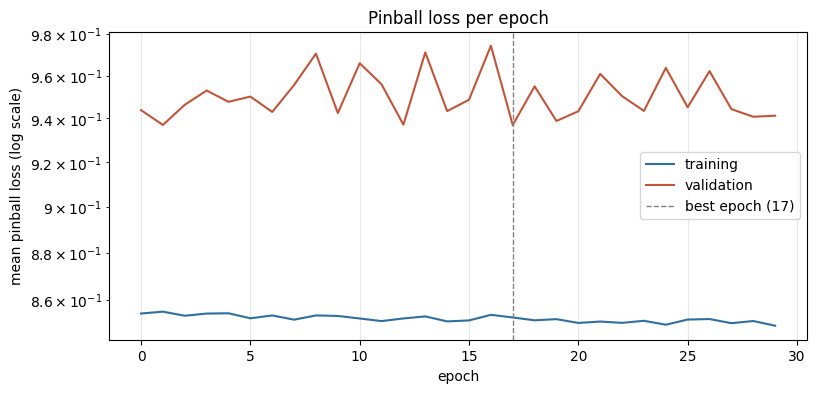

In [53]:
curves = pd.DataFrame(history)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(curves["epoch"], curves["train_loss"], label="training", color="#2f6f9f")
ax.plot(curves["epoch"], curves["val_loss"], label="validation", color="#c1553b")
ax.axvline(best_epoch, ls="--", color="gray", lw=1, label=f"best epoch ({best_epoch})")
ax.set_yscale("log")
ax.set_xlabel("epoch")
ax.set_ylabel("mean pinball loss (log scale)")
ax.set_title("Pinball loss per epoch")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

---

## Save the checkpoint

*Lesson 8, Saving and Loading.* A checkpoint is more than the weights:
the network is useless without the scaler that prepared its inputs,
so the scaler's mean and std are saved beside the `state_dict`, as
tensors, which `torch.load` accepts by default.

In [54]:
torch.save({"state_dict": model.state_dict(),
            "hidden": CONFIG["hidden"],
            "mean": torch.tensor(scaler.mean_, dtype=torch.float32),
            "std": torch.tensor(scaler.scale_, dtype=torch.float32)}, "taxi.pt")
print("saved taxi.pt:", sorted(torch.load("taxi.pt")))

saved taxi.pt: ['hidden', 'mean', 'state_dict', 'std']


---

## Predict from the checkpoint

Rebuild the architecture with `make_model()`, load the saved weights
into it, and standardise with the **saved** mean and std: what a
separate prediction script would do, using nothing from the training
cells. `map_location="cpu"` loads a file saved on a GPU onto any
machine, and `.cpu()` before `.numpy()` does the same for the
predictions.

The validation score below should equal Step 5c's best. Expect just
under 1 there and about −0.94 on the leaderboard: the validation
days are the slower ones (their 90th percentile is 25.8 minutes, the
leaderboard's 25.3). Read a validation score as a comparison between
your own variants, not as a forecast of your rank.

In [55]:
ckpt = torch.load("taxi.pt", map_location="cpu")
model = make_model()
model.load_state_dict(ckpt["state_dict"])
model.eval()


def standardise(frame):
    """The saved scaler, applied to a frame holding the 12 feature columns."""
    return (to_t(frame[FEATURES]) - ckpt["mean"]) / ckpt["std"]


with torch.no_grad():
    val_pred = model(standardise(X_val)).squeeze(1).cpu().numpy()
    sub_pred = model(standardise(X_submission)).squeeze(1).cpu().numpy()
val_score, val_kept = leaderboard_score(val_pred, y_val)
print(f"validation, from the checkpoint: -pinball {val_score:.4f}, {val_kept:.1f}% kept")
assert abs(-val_score - best_val) < 1e-4, (
    "the reloaded checkpoint does not reproduce Step 5c's best validation loss")

validation, from the checkpoint: -pinball -0.9370, 89.5% kept


### Check the file, then write it

The scorer rejects a missing, unknown, duplicate or empty id, a
non-number, a `NaN` or an infinity, and a rejected file still uses
one of your two daily submissions. So the cell writes
`submission.csv`, reads it back and checks it the way the scorer will,
before you submit.

In [56]:
submission = pd.DataFrame({"id": X_submission["id"], "prediction": sub_pred.round(3)})
submission.to_csv("submission.csv", index=False)

check = pd.read_csv("submission.csv")
promises = check["prediction"]
assert list(check.columns) == ["id", "prediction"], "the header must be id,prediction"
assert len(check) == len(X_submission) and check["id"].is_unique, "one row per id of X_submission.csv"
assert set(check["id"]) == set(X_submission["id"]), "the ids must be exactly those of X_submission.csv"
assert np.isfinite(promises).all(), "every prediction must be a finite number of minutes"
print(f"submission.csv: {len(check)} rows, promises from {promises.min():.1f} to "
      f"{promises.max():.1f} min, mean {promises.mean():.2f}: ready to submit")

submission.csv: 10461 rows, promises from 3.0 to 114.2 min, mean 18.57: ready to submit


---

## Submit

**Two submissions a day.** Each ML-Arena account may submit **2 times
per rolling 24 hours, across all challenges**: Session 3 submissions
from the last 24 hours count, and a file the scorer rejects still
uses one. Choose on the validation score above, then submit once.

In [57]:
result = client.submit(challenge_id=CHALLENGE_ID, files=["submission.csv"],
                       agent_name="taxi-mlp")
print(result)

{'attache_agent_id': 8683, 'agent_id': 8683, 'deploy': {'deployment_id': 8444, 'message': 'Deployment started successfully', 'status': 'deploy_queue'}}


Scoring takes a moment. Then:

In [58]:
client.leaderboard(CHALLENGE_ID)

,AgentName,AvatarKey,EloScore,EloVariance,FrontendPrecision,HasGpu,IsContinuous,IsEloRanked,IsMyAgent,LastRun,...,NumberOfRuns,Rank,RewardCi95,SimulationVersion,SubscriptionDate,TeamId,TeamMembers,TeamName,Username,agentAttachId
0,taxi-mlp,None,1200.0,None,2,False,False,False,False,2026-09-11 14:21:49,...,1,1,None,file_v1,2026-09-11 14:21:13,None,[],None,martindelamare,8679
1,taxi-mlp,None,1200.0,None,2,False,False,False,False,2026-09-11 14:20:43,...,1,2,None,file_v1,2026-09-11 14:13:45,None,[],None,funnyvamp,8674
2,taxi-mlp,None,1200.0,None,2,False,False,False,False,2026-09-11 14:29:54,...,1,3,None,file_v1,2026-09-11 14:29:41,None,[],None,martindelamare,8681
3,taxi-mlp,None,1200.0,None,2,False,False,False,False,2026-09-11 13:51:20,...,1,4,None,file_v1,2026-09-11 13:46:41,None,[],None,martindelamare,8673
4,taxi-mlp,None,1200.0,None,2,False,False,False,False,2026-09-11 13:45:16,...,1,5,None,file_v1,2026-09-11 13:43:54,None,[],None,anne-sophie,8671
5,taxi-mlp,None,1200.0,None,2,False,False,False,False,2026-09-11 13:03:50,...,1,6,None,file_v1,2026-09-11 13:01:18,None,[],None,klaara.huima,8668
6,taxi-mlp,shapes:77k1laip,1200.0,None,2,False,False,False,False,2026-09-10 15:16:01,...,1,7,None,file_v1,2026-09-10 15:15:45,None,[],None,raphael,8661
7,taxi-mlp,None,1200.0,None,2,False,False,False,False,2026-09-11 13:45:29,...,1,8,None,file_v1,2026-09-11 13:44:06,None,[],None,Dave78300,8672
8,taxi-mlp,None,1200.0,None,2,False,False,False,False,2026-09-11 13:44:46,...,1,8,None,file_v1,2026-09-11 13:40:11,None,[],None,Dave78300,8669
9,__benchmark__,shapes:77k1laip,NaN,None,2,False,False,False,False,2026-09-10 15:12:44,...,1,10,None,file_v1,2026-09-10 15:01:57,None,[],None,raphael,8659


---

## Going further

Compare each variant on the validation part, with `evaluate` or
`leaderboard_score`, not by submitting: every submission uses one of
your two daily slots.

- **Test different model size, different batch size, different learning rate
- **The usual loss.** In `train_one_epoch`, replace
  `pinball(model(xb), yb)` with `nn.functional.mse_loss(model(xb), yb)`,
  set `model = make_model()`, rerun Steps 3 and 5c, and read `kept`:
  the network now aims at the average trip and keeps about half its
  promises.
